In [25]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [26]:
# Load your dataset
df = pd.read_csv("emails.csv")

In [27]:
# Preview dataset
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [29]:
df = df.rename(columns={"spam": "label", "text": "message"})

In [30]:
df.columns

Index(['message', 'label'], dtype='object')

In [31]:
if df['label'].dtype == 'object':
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [32]:
print(df['label'].value_counts())

label
0    4360
1    1368
Name: count, dtype: int64


In [33]:
df.isnull().sum()

# Drop missing rows if any
df = df.dropna()

In [34]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4582
Testing Samples: 1146


In [35]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Feature matrix shape:", X_train_tfidf.shape)

Feature matrix shape: (4582, 33465)


In [36]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred = model.predict(X_test_tfidf)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9834205933682374


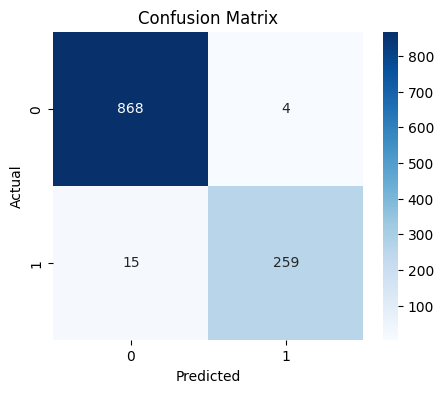

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.95      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.98      1146
weighted avg       0.98      0.98      0.98      1146



In [41]:
def predict_email(text):
    text_vector = vectorizer.transform([text])
    prediction = model.predict(text_vector)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Not Spam"

In [42]:
print(predict_email("Congratulations! You have won $1000"))
print(predict_email("localized software.  hello , we would like to offer localized software versions"))

Not Spam
Spam


In [43]:
import pickle

pickle.dump(model, open("email_spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))